# Analiza

In [85]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie do obliczeń: {device}")

Używane urządzenie do obliczeń: cuda


In [ ]:
IMG_SIZE = 224
data_dir = './Waste-Classification-1'


In [ ]:
temp_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

temp_dataset = datasets.ImageFolder(
    os.path.join(data_dir, 'train'),
    transform=temp_transforms
)

temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False, num_workers=2)

mean = torch.zeros(3)
std  = torch.zeros(3)
total = 0

for images, _ in temp_loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total += batch_size

mean /= total
std  /= total

print(f"Mean: {mean}")
print(f"Std:  {std}")

means = mean.tolist()
stds = std.tolist()

In [ ]:
data_transforms = {
    'train': transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(means, stds)
    ]),
    'valid': transforms.Compose([
        transforms.Resize(int(IMG_SIZE * 256/224)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(means, stds)
    ]),
    'test': transforms.Compose([
        transforms.Resize(int(IMG_SIZE * 256/224)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(means, stds)
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
    for x in ['train', 'valid', 'test']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2, pin_memory=True)
    for x in ['train', 'valid', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid', 'test']}
class_names = image_datasets['train'].classes

for split in ['train', 'valid', 'test']:
    targets = image_datasets[split].targets
    print(f"{split} ({dataset_sizes[split]}):")
    for i, name in enumerate(class_names):
        print(f"  {name}: {targets.count(i)} ({targets.count(i) / dataset_sizes[split] * 100:.1f}%)")
    print()

train (1767):
  cardboard: 275 (15.6%)
  glass: 352 (19.9%)
  metal: 284 (16.1%)
  paper: 423 (23.9%)
  plastic: 340 (19.2%)
  trash: 93 (5.3%)

valid (504):
  cardboard: 84 (16.7%)
  glass: 102 (20.2%)
  metal: 85 (16.9%)
  paper: 107 (21.2%)
  plastic: 96 (19.0%)
  trash: 30 (6.0%)

test (253):
  cardboard: 44 (17.4%)
  glass: 47 (18.6%)
  metal: 40 (15.8%)
  paper: 64 (25.3%)
  plastic: 44 (17.4%)
  trash: 14 (5.5%)



# Definiowanie Modelu

In [88]:
class NikTechTrashClassificationCnn(nn.Module):
    def __init__(self, num_classes, img_size):
        super(NikTechTrashClassificationCnn, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        fc1_size = 256 * (img_size // 16) * (img_size // 16)
        self.fc1 = nn.Linear(fc1_size, 512)
        self.bn5 = nn.BatchNorm1d(512)
        
        self.dropout = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.bn5(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class_count = len(class_names)

model = NikTechTrashClassificationCnn(num_classes=class_count, img_size=IMG_SIZE).to(device)

print(model)
print(f"\nModel pomyślnie załadowany na urządzenie: {device}")

NikTechTrashClassificationCnn(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (bn5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_

# Pętla treningowa

In [89]:
#HIPERPARAMETRY
NUM_EPOCHS = 120
LEARNING_RATE = 0.001

In [ ]:
class_counts  = [image_datasets['train'].targets.count(i) for i in range(class_count)]

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.001,
    epochs=NUM_EPOCHS,
    steps_per_epoch=len(dataloaders['train'])
)

In [91]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':  []
}

best_val_acc    = 0.0
best_model_path =  'best_model.pth'
patience_counter = 0
early_stop_patience = 20

In [92]:
def train_epoch(model, loader, criterion, optimizer, device, scheduler):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        running_correct += (predicted == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}] Loss: {loss.item():.4f}")

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc


def validate_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            running_correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = running_correct / total
    return epoch_loss, epoch_acc



In [93]:
training_start = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 40)

    train_loss, train_acc = train_epoch(
        model, dataloaders['train'], criterion, optimizer, device, scheduler
    )

    val_loss, val_acc = validate_epoch(
        model, dataloaders['valid'], criterion, device
    )

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Trening: Loss {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
    print(f"Walidacja: Loss: {val_loss:.4f}  | Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch':           epoch + 1,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc':         best_val_acc,
            'class_names':     class_names,
            'img_size':        IMG_SIZE,
        }, best_model_path)
        print(f"Najlepszy model zapisany (acc: {best_val_acc*100:.2f}%)")
    else:
        patience_counter += 1
        print(f"Brak poprawy ({patience_counter}/{early_stop_patience})")
        if patience_counter >= early_stop_patience:
            print("Zatrzymanie")
            break

total_time = time.time() - training_start

print("\n" + "=" * 60)
print(f"Training skończony, najlepsza dokładnosc na zbiorze walidacyjnym: {best_val_acc*100:.2f}%")
print(f"Czas trenowania: {total_time//60:.0f}m {total_time%60:.0f}s")
print("=" * 60)


Epoch [1/120]
----------------------------------------
  Batch [10/56] Loss: 1.8875
  Batch [20/56] Loss: 1.6543
  Batch [30/56] Loss: 1.3117
  Batch [40/56] Loss: 1.0302
  Batch [50/56] Loss: 1.4481
Trening: Loss 1.4202 | Acc: 46.58%
Walidacja: Loss: 0.9376  | Acc: 68.45%
Najlepszy model zapisany (acc: 68.45%)

Epoch [2/120]
----------------------------------------
  Batch [10/56] Loss: 1.2648
  Batch [20/56] Loss: 0.9563
  Batch [30/56] Loss: 1.6475
  Batch [40/56] Loss: 1.0567
  Batch [50/56] Loss: 0.9940
Trening: Loss 1.1321 | Acc: 58.63%
Walidacja: Loss: 0.8197  | Acc: 70.63%
Najlepszy model zapisany (acc: 70.63%)

Epoch [3/120]
----------------------------------------
  Batch [10/56] Loss: 1.1285
  Batch [20/56] Loss: 0.8685
  Batch [30/56] Loss: 0.8689
  Batch [40/56] Loss: 1.0022
  Batch [50/56] Loss: 1.2692
Trening: Loss 1.0117 | Acc: 62.42%
Walidacja: Loss: 0.7784  | Acc: 71.83%
Najlepszy model zapisany (acc: 71.83%)

Epoch [4/120]
----------------------------------------
  

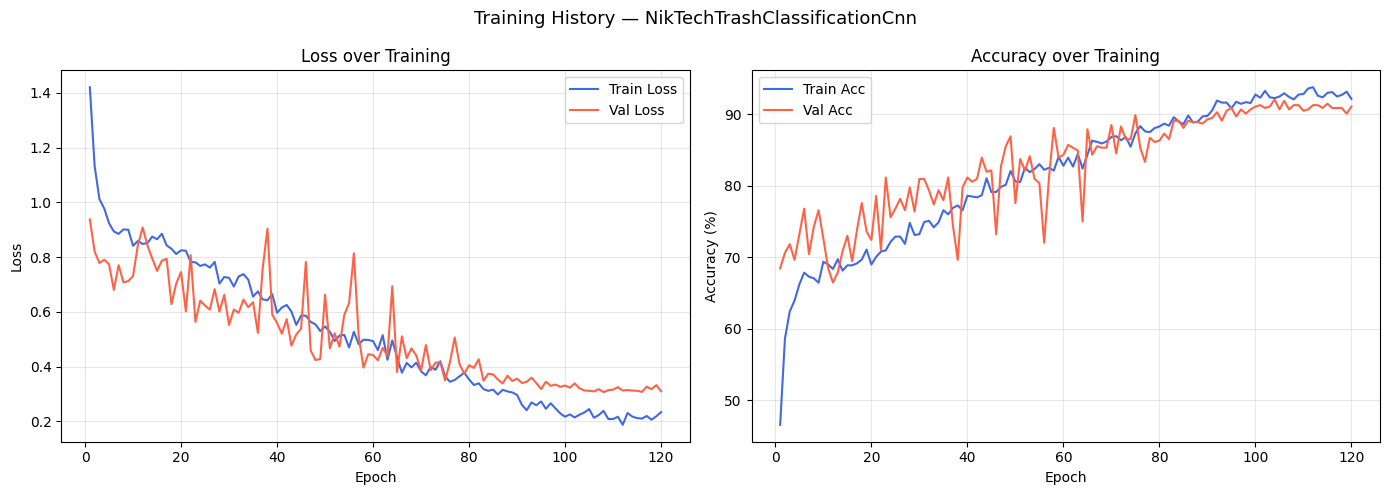

In [94]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='royalblue')
ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato')
ax1.set_title('Loss over Training')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', color='royalblue')
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   color='tomato')
ax2.set_title('Accuracy over Training')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Training History — NikTechTrashClassificationCnn', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Weryfikacja ze zbiorem testowym


In [95]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best model from epoch {checkpoint['epoch']} (val acc: {checkpoint['val_acc']*100:.2f}%)")

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in dataloaders['test']:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

Loaded best model from epoch 104 (val acc: 92.06%)


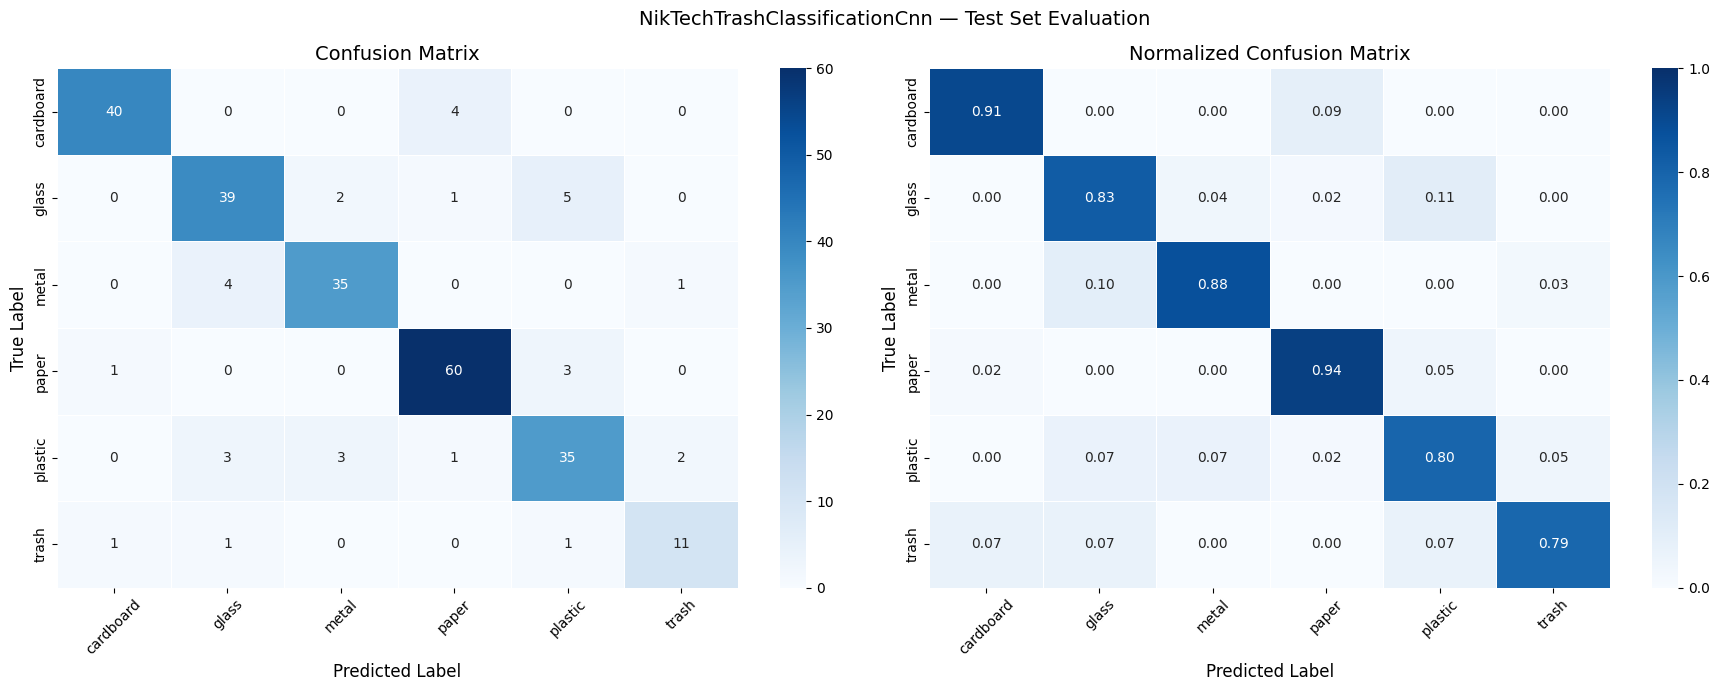

              precision    recall  f1-score   support

   cardboard     0.9524    0.9091    0.9302        44
       glass     0.8298    0.8298    0.8298        47
       metal     0.8750    0.8750    0.8750        40
       paper     0.9091    0.9375    0.9231        64
     plastic     0.7955    0.7955    0.7955        44
       trash     0.7857    0.7857    0.7857        14

    accuracy                         0.8696       253
   macro avg     0.8579    0.8554    0.8565       253
weighted avg     0.8699    0.8696    0.8696       253

Dokładność względem zbioru testowego 86.96%


In [96]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names, linewidths=0.5, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('NikTechTrashClassificationCnn — Test Set Evaluation', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
print(f"Dokładność względem zbioru testowego {(all_labels == all_preds).mean()*100:.2f}%")

# Wnioski

1. Augmentacja danych pogarszała wyniki
2. Uzycie weighted loss zmniejsza dokladnosc